In [1]:
# Importation of modules and library
import matplotlib.pyplot as plt            # Module to produce figure
import matplotlib.colors as colors
import cartopy.crs as ccrs                 # Import cartopy ccrs
import cartopy.feature as cfeature         # Import cartopy common features
import numpy as np
import cartopy.geodesic as cgeo
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import numpy as np
import cartopy.mpl.ticker as cticker
from matplotlib import font_manager as mfonts
import matplotlib.ticker as mticker
import matplotlib.patches as patches
# import geopandas as gpd
import matplotlib.patches as mpatches

# import ee
# import cartoee as cee
import cartopy.crs as ccrs
# from matplotlib_scalebar.scalebar import ScaleBar

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


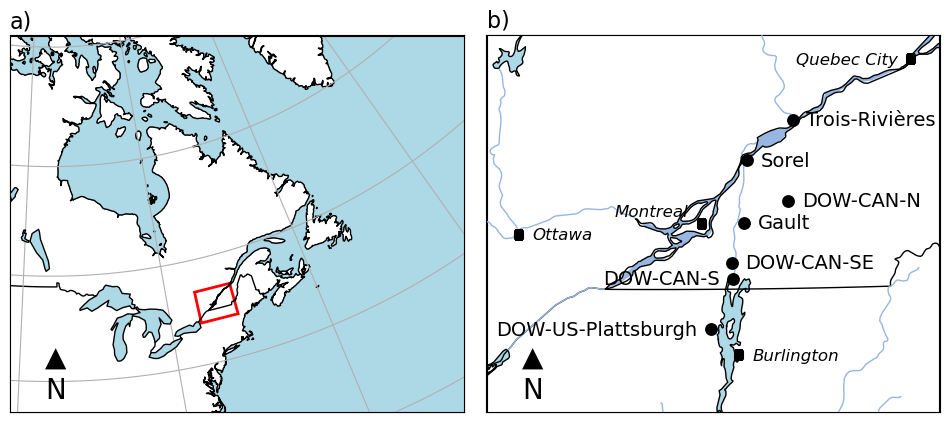

In [3]:
# Figure settings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.89),
                               gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1]}
                               )
ax = [ax1, ax2]
for ax in [ax1, ax2]:
    ax.set_xticks([])
    ax.set_yticks([])
    
# Adjust space between subplots
plt.subplots_adjust(wspace=0.05)

ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.LambertConformal())
ax1.set_extent([-100.9, -44, 37, 65], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND.with_scale('50m'), facecolor='white', edgecolor='black', linewidth=0.5)  # add map
ax1.add_patch(mpatches.Rectangle(xy=[-76, 44], width=5, height=3,
                                facecolor='none', edgecolor='r', linewidth=2,
                                transform=ccrs.PlateCarree()))
ax1.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='lightblue')  # add ocean

ax1.gridlines()
ax1.coastlines()
ax1.add_feature(cfeature.LAKES.with_scale('110m'),edgecolor='black',facecolor='lightblue', zorder=3)  # couche lac    

ax1.add_feature(cfeature.BORDERS)

####################################################
####################################################
# Set the domain for defining the plot region
latN = 47               # latitude max (Nord)
latS = 44                # latitude min (Sud)
lonW = -76               # longitude min (Ouest)
lonE = -71               # longitude max (Est)
cLat = (latN + latS)/2   # latitude centrale
cLon = (lonW + lonE )/2  # longitude centrale

proj2 = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
ax2 = fig.add_subplot(1, 2, 2, projection=proj2)
ax2.set_extent([lonW,lonE,latS,latN])

# Set geographic features
ax2.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=1)   # couche ocean
ax2.add_feature(cfeature.LAND.with_scale('10m'),facecolor='white', zorder=2)  # couche land
ax2.add_feature(cfeature.LAKES.with_scale('10m'),edgecolor='black',facecolor='lightblue', zorder=3)  # couche lac    
ax2.add_feature(cfeature.BORDERS.with_scale('10m'), zorder=4)    # couche frontieres
ax2.add_feature(cfeature.RIVERS.with_scale('10m'), zorder=5)     # couche rivières 
coast = cfeature.NaturalEarthFeature(category='physical', scale='10m',facecolor='none', name='coastline') # couche côtes
ax2.add_feature(coast, edgecolor='black', zorder=6)
states_provinces = cfeature.NaturalEarthFeature(category='cultural',name='admin_1_states_provinces_lines',scale='10m',facecolor='none') # Couche provinces

#Ajouter les villes 
cities = {
    'Sorel': [ -73.110328, 46.030244],
    'Trois-Rivières': [ -72.581353, 46.349836],
    'Gault': [ -73.149006,45.535022],
    'DOW-CAN-N': [-72.644103,45.704814],
    'DOW-US-Plattsburgh': [ -73.526291,44.684823],
    'DOW-CAN-S':[-73.271936, 45.085246],
    'DOW-CAN-SE':[-73.2854085, 45.2129313]
}

xytext_offset = {'UQAM': (5, 5), 'Albany': (-10, -10), 'Colorado': (5, -10), 'McGill': (5, 5)}
va = 'center'

colors = {'UQAM': 'k', 'Albany': 'k', 'Colorado': 'k', 'McGill': 'k'}

for city in cities:
    coord = cities[city]
    ax2.scatter(coord[0], coord[1], s=60, c='k', edgecolor='k', linewidth=1.5, alpha=1.0,
                transform=ccrs.PlateCarree(), zorder=10)
    
city = 'Sorel'
ax2.text(cities[city][0] + 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='left', va='center', color='black', zorder=20)
city = 'Trois-Rivières'
ax2.text(cities[city][0] + 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='left', va='center', color='black', zorder=20)
city = 'Gault'
ax2.text(cities[city][0] + 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='left', va='center', color='black', zorder=20)
city = 'DOW-CAN-N'
ax2.text(cities[city][0] + 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='left', va='center', color='black', zorder=20)
city = 'DOW-CAN-SE'
ax2.text(cities[city][0] + 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='left', va='center', color='black', zorder=20)
city = 'DOW-CAN-S'
ax2.text(cities[city][0] - 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='right', va='center', color='black', zorder=20)
city = 'DOW-US-Plattsburgh'
ax2.text(cities[city][0] - 0.15, cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=14, ha='right', va='center', color='black', zorder=20)



other_cities = {'Montreal': [-73.6273, 45.5217], 'Ottawa': [-75.6972, 45.4215], 'Quebec City': [-71.2082, 46.8139], 'Albany': [-73.7562, 42.6526], 'Burlington': [-73.2121, 44.4759]}

for city in other_cities:
    coord = other_cities[city]
    ax2.scatter(coord[0], coord[1], s=40, c='k', edgecolor='k', linewidth=1.5, alpha=1.0,
                transform=ccrs.PlateCarree(), zorder=10,marker='s')
city = 'Montreal'
ax2.text(other_cities[city][0] - 0.15, other_cities[city][1] + 0.1, city,
        transform=ccrs.PlateCarree(),
        fontsize=12, fontstyle='italic', ha='right', va='center', color='black', zorder=20)
city = 'Ottawa'
ax2.text(other_cities[city][0] + 0.15, other_cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=12, fontstyle='italic', ha='left', va='center', color='black', zorder=20)
city = 'Quebec City'
ax2.text(other_cities[city][0] - 0.15, other_cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=12, fontstyle='italic', ha='right', va='center', color='black', zorder=20)
city = 'Burlington'
ax2.text(other_cities[city][0] + 0.15, other_cities[city][1], city,
        transform=ccrs.PlateCarree(),
        fontsize=12, fontstyle='italic', ha='left', va='center', color='black', zorder=20)

#Add arrow annotation to indicate North
left = 0.1
bottom = 0.1
text = u'\u25B2\nN'
fontsize = 20
family = 'Arial'

ax1.text(left, bottom, text, ha='center', va='center', fontsize=fontsize, family=family, rotation=0, transform=ax1.transAxes)
ax2.text(left, bottom, text, ha='center', va='center', fontsize=fontsize, family=family, rotation=0, transform=ax2.transAxes)

# Adding titles with letters
letters = ['a)', 'b)']
for i, letter in enumerate(letters):
    ax = [ax1, ax2]
    ax[i].set_title(f"{letters[i]}", fontsize=16, loc='left')


plt.show()


# fig.savefig('figures/map.png', format='png', dpi=1200)